# Rolling Evaluation: Full Retrain vs Incremental Fine-tuning

Compare two strategies for updating a **Johnson SU Probabilistic Transformer**
as new monthly data arrives:

| Method | Description |
|--------|-------------|
| **Full Retrain** | Build a new model from random weights each month, train on *all* available data (30 epochs) |
| **Incremental** | Keep previous weights, fine-tune on all available data with lower learning rate (10 epochs) |

**Setup:**
- Initial training period: 2 years (Feb 2023 – Jan 2025)
- Rolling evaluation: 12 monthly windows (Feb 2025 – Jan 2026)
- Model: `ProbabilisticTransformer` with `JohnsonSUHead`

In [12]:
import os
import sys
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

current_dir = Path.cwd()
project_root = str(current_dir) if (current_dir / 'config.py').exists() else str(current_dir.parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from config import DataConfig, ExperimentConfig, ModelConfig, TrainingConfig
from models import ProbabilisticTransformer
from core.experiment_utils import (
    CANONICAL_MODEL_CONFIG, CANONICAL_TRAIN_CONFIG, set_seeds,
    load_cache, save_cache,
)
from core.evaluator import Evaluator
from transformations import StandardScalingTransformation
from data.loader import DataLoader

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

try:
    gpus = tf.config.experimental.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs: {len(gpus)}")
except Exception:
    pass

GPUs: 1


In [13]:
INPUT_WINDOW = 168
OUTPUT_HORIZON = 24
TRAIN_START = pd.Timestamp("2023-02-01")
INITIAL_TRAIN_END = pd.Timestamp("2025-02-01")

RETRAIN_EPOCHS = 30
RETRAIN_LR = 7e-4
RETRAIN_PATIENCE = 5

FINETUNE_EPOCHS = 10
FINETUNE_LR = 1e-4
FINETUNE_PATIENCE = 3

RESULTS_DIR = Path(project_root) / "results" / "rolling_evaluation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = RESULTS_DIR / "results.json"

print("Full retrain :", f"{RETRAIN_EPOCHS} epochs, LR={RETRAIN_LR}, patience={RETRAIN_PATIENCE}")
print("Fine-tune    :", f"{FINETUNE_EPOCHS} epochs, LR={FINETUNE_LR}, patience={FINETUNE_PATIENCE}")

Full retrain : 30 epochs, LR=0.0007, patience=5
Fine-tune    : 10 epochs, LR=0.0001, patience=3


In [14]:
loader = DataLoader(DataConfig())
prices, exog = loader.load_raw_data()
df_full = prices.to_frame(name="Prices")
if exog is not None:
    df_full = df_full.join(exog)
df_full.index = pd.to_datetime(df_full.index)
df_full = df_full.sort_index()

month_starts = pd.date_range(INITIAL_TRAIN_END, periods=13, freq="MS")
n_windows = len(month_starts) - 1

print(f"Dataset : {df_full.index[0]} → {df_full.index[-1]}  ({len(df_full):,} rows, {df_full.shape[1]} features)")
print(f"\nRolling schedule ({n_windows} months):")
for i in range(n_windows):
    n_tr = len(df_full[(df_full.index >= TRAIN_START) & (df_full.index < month_starts[i])])
    n_te = len(df_full[(df_full.index >= month_starts[i]) & (df_full.index < month_starts[i + 1])])
    print(f"  {i+1:2d}. Train → {month_starts[i].strftime('%Y-%m-%d')}, "
          f"predict {month_starts[i].strftime('%b %Y'):>8s}  "
          f"({n_tr:,} train / {n_te:,} test hours)")

Dataset : 2023-02-01 00:00:00 → 2026-01-31 23:00:00  (26,304 rows, 28 features)

Rolling schedule (12 months):
   1. Train → 2025-02-01, predict Feb 2025  (17,544 train / 672 test hours)
   2. Train → 2025-03-01, predict Mar 2025  (18,216 train / 744 test hours)
   3. Train → 2025-04-01, predict Apr 2025  (18,960 train / 720 test hours)
   4. Train → 2025-05-01, predict May 2025  (19,680 train / 744 test hours)
   5. Train → 2025-06-01, predict Jun 2025  (20,424 train / 720 test hours)
   6. Train → 2025-07-01, predict Jul 2025  (21,144 train / 744 test hours)
   7. Train → 2025-08-01, predict Aug 2025  (21,888 train / 744 test hours)
   8. Train → 2025-09-01, predict Sep 2025  (22,632 train / 720 test hours)
   9. Train → 2025-10-01, predict Oct 2025  (23,352 train / 744 test hours)
  10. Train → 2025-11-01, predict Nov 2025  (24,096 train / 720 test hours)
  11. Train → 2025-12-01, predict Dec 2025  (24,816 train / 744 test hours)
  12. Train → 2026-01-01, predict Jan 2026  (25,560 t

In [15]:
def create_sequences(data_values, input_window, output_horizon):
    n_seq = len(data_values) - input_window - output_horizon + 1
    if n_seq <= 0:
        return np.empty((0, input_window, data_values.shape[1])), np.empty((0, output_horizon))
    X, y = [], []
    for i in range(n_seq):
        w = data_values[i : i + input_window]
        t = data_values[i + input_window : i + input_window + output_horizon, 0]
        if not (np.isnan(w).any() or np.isnan(t).any()):
            X.append(w)
            y.append(t)
    return np.array(X), np.array(y)


def prepare_window(train_end, test_end):
    """Prepare scaled train / val / test arrays and a fresh scaler for one rolling window."""
    train_all = df_full[(df_full.index >= TRAIN_START) & (df_full.index < train_end)]
    val_n = int(len(train_all) * 0.1)
    train_df = train_all.iloc[:-val_n]
    val_df = train_all.iloc[-val_n:]

    ctx_start = train_end - pd.Timedelta(hours=INPUT_WINDOW)
    test_df = df_full[(df_full.index >= ctx_start) & (df_full.index < test_end)]

    X_tr, y_tr = create_sequences(train_df.values, INPUT_WINDOW, OUTPUT_HORIZON)
    X_va, y_va = create_sequences(val_df.values, INPUT_WINDOW, OUTPUT_HORIZON)
    X_te, y_te = create_sequences(test_df.values, INPUT_WINDOW, OUTPUT_HORIZON)

    scaler = StandardScalingTransformation()
    scaler.fit(X_tr, y_tr)
    X_tr_s, y_tr_s = scaler.transform(X_tr, y_tr)
    X_va_s, y_va_s = scaler.transform(X_va, y_va)
    X_te_s, _ = scaler.transform(X_te, y_te)

    return X_tr_s, y_tr_s, X_va_s, y_va_s, X_te_s, y_te, scaler, X_tr.shape[-1]


def build_model(n_features, lr):
    """Build a fresh ProbabilisticTransformer with Johnson SU head."""
    conf = ExperimentConfig(
        name="rolling",
        data_config=DataConfig(input_window=INPUT_WINDOW, output_horizon=OUTPUT_HORIZON),
        model_config=ModelConfig(**CANONICAL_MODEL_CONFIG),
        training_config=TrainingConfig(learning_rate=lr),
        head_type="johnson_su",
    )
    m = ProbabilisticTransformer(conf)
    m.build_model(n_features)
    return m


def fit_model(model, X_tr, y_tr, X_va, y_va, epochs, patience, lr=None):
    """Train or fine-tune a model. Recompiles with *lr* when provided. Returns wall-clock seconds."""
    if lr is not None:
        model.keras_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss=lambda yt, yp: model.head.loss(yt, yp),
        )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=max(patience - 1, 2), min_lr=1e-7
        ),
    ]
    t0 = time.time()
    model.keras_model.fit(
        X_tr, y_tr,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_va, y_va),
        callbacks=callbacks,
        verbose=0,
    )
    return time.time() - t0


def evaluate_window(model, scaler, X_te_s, y_te):
    """Evaluate on one test window. Returns (metrics_dict, y_pred_original)."""
    evaluator = Evaluator(model, scaler)
    metrics = evaluator.evaluate(X_te_s, y_te)
    y_pred = evaluator.generate_forecasts(X_te_s)
    return metrics, y_pred


print("Helpers ready.")

Helpers ready.


---
## Method 1 — Full Retrain

For every monthly window the model is **built from scratch** (random weight
initialisation) and trained for up to 30 epochs on the entire expanding
training set.  This is the gold-standard approach but also the most expensive.

In [16]:
print("=" * 70)
print("  METHOD 1: FULL RETRAIN FROM SCRATCH")
print("=" * 70)

RETRAIN_KEY = "Full Retrain"
cache = load_cache(CACHE_FILE)

if RETRAIN_KEY in cache:
    results_retrain = cache[RETRAIN_KEY]
    print(f"[{RETRAIN_KEY}] found in cache — skipping ({len(results_retrain)} windows).")
else:
    results_retrain = []
    for w in range(n_windows):
        train_end = month_starts[w]
        test_end = month_starts[w + 1]
        label = train_end.strftime("%b %Y")

        print(f"\n--- Window {w + 1}/{n_windows}: {label} ---")

        X_tr, y_tr, X_va, y_va, X_te, y_te, scaler, n_feat = prepare_window(train_end, test_end)
        print(f"  sequences  train={X_tr.shape[0]:,}  val={X_va.shape[0]:,}  test={X_te.shape[0]:,}")

        tf.keras.backend.clear_session()
        gc.collect()
        set_seeds(w)

        model = build_model(n_feat, RETRAIN_LR)
        t = fit_model(model, X_tr, y_tr, X_va, y_va, RETRAIN_EPOCHS, RETRAIN_PATIENCE)
        metrics, y_pred = evaluate_window(model, scaler, X_te, y_te)
        metrics["training_time"] = t

        results_retrain.append({"month": label, **metrics})
        print(f"  MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  "
              f"CRPS={metrics['CRPS']:.4f}  PICP={metrics['PICP']:.3f}  time={t:.1f}s")

    del model
    gc.collect()
    tf.keras.backend.clear_session()
    cache[RETRAIN_KEY] = results_retrain
    save_cache(CACHE_FILE, cache)

print("\nDone — full retrain.")

  METHOD 1: FULL RETRAIN FROM SCRATCH
[Full Retrain] found in cache — skipping (12 windows).

Done — full retrain.


---
## Method 2 — Incremental Fine-tuning

The model is trained **once** on the initial 2-year window (same settings as
Method 1).  For every subsequent month, the existing weights are kept and the
model is **fine-tuned** on the full expanding training set with a lower
learning rate (1e-4) and fewer epochs (10).

The key savings come from:
1. Starting from pre-trained weights (faster convergence)
2. Fewer training epochs per update
3. No model rebuild overhead

In [17]:
print("=" * 70)
print("  METHOD 2: INCREMENTAL FINE-TUNING")
print("=" * 70)

FINETUNE_KEY = "Incremental Fine-tuning"
cache = load_cache(CACHE_FILE)

if FINETUNE_KEY in cache:
    results_finetune = cache[FINETUNE_KEY]
    print(f"[{FINETUNE_KEY}] found in cache — skipping ({len(results_finetune)} windows).")
else:
    results_finetune = []
    inc_model = None

    for w in range(n_windows):
        train_end = month_starts[w]
        test_end = month_starts[w + 1]
        label = train_end.strftime("%b %Y")

        print(f"\n--- Window {w + 1}/{n_windows}: {label} ---")

        X_tr, y_tr, X_va, y_va, X_te, y_te, scaler, n_feat = prepare_window(train_end, test_end)
        print(f"  sequences  train={X_tr.shape[0]:,}  val={X_va.shape[0]:,}  test={X_te.shape[0]:,}")

        if w == 0:
            tf.keras.backend.clear_session()
            gc.collect()
            set_seeds(0)
            inc_model = build_model(n_feat, RETRAIN_LR)
            t = fit_model(inc_model, X_tr, y_tr, X_va, y_va, RETRAIN_EPOCHS, RETRAIN_PATIENCE)
            mode = "initial"
        else:
            t = fit_model(inc_model, X_tr, y_tr, X_va, y_va,
                           FINETUNE_EPOCHS, FINETUNE_PATIENCE, lr=FINETUNE_LR)
            mode = "fine-tune"

        metrics, y_pred = evaluate_window(inc_model, scaler, X_te, y_te)
        metrics["training_time"] = t

        results_finetune.append({"month": label, **metrics})
        print(f"  [{mode:>9s}] MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  "
              f"CRPS={metrics['CRPS']:.4f}  PICP={metrics['PICP']:.3f}  time={t:.1f}s")

    del inc_model
    gc.collect()
    tf.keras.backend.clear_session()
    cache[FINETUNE_KEY] = results_finetune
    save_cache(CACHE_FILE, cache)

print("\nDone — incremental fine-tuning.")

  METHOD 2: INCREMENTAL FINE-TUNING
[Incremental Fine-tuning] found in cache — skipping (12 windows).

Done — incremental fine-tuning.


---
## Comparison

In [18]:
# Build from cache for reliable reload (like notebook 7)
cache = load_cache(CACHE_FILE)
results_retrain = cache.get("Full Retrain", [])
results_finetune = cache.get("Incremental Fine-tuning", [])

df_rt = pd.DataFrame(results_retrain)
df_ft = pd.DataFrame(results_finetune)

if df_rt.empty or df_ft.empty:
    print("Run the Full Retrain and Incremental Fine-tuning cells first to populate the cache.")
else:
    compare = pd.DataFrame({
    "Month": df_rt["month"],
    "MAE (retrain)": df_rt["MAE"].values,
    "MAE (incr.)": df_ft["MAE"].values,
    "\u0394MAE": df_ft["MAE"].values - df_rt["MAE"].values,
    "CRPS (retrain)": df_rt["CRPS"].values,
    "CRPS (incr.)": df_ft["CRPS"].values,
    "\u0394CRPS": df_ft["CRPS"].values - df_rt["CRPS"].values,
    "Time retrain (s)": df_rt["training_time"].values,
    "Time incr. (s)": df_ft["training_time"].values,
    "Speedup": df_rt["training_time"].values / df_ft["training_time"].values,
})
display(compare.style.format(precision=4).set_caption("Per-month comparison"))

,Month,MAE (retrain),MAE (incr.),ΔMAE,CRPS (retrain),CRPS (incr.),ΔCRPS,Time retrain (s),Time incr. (s),Speedup
0,Feb 2025,17.1715,18.5456,1.3741,12.5175,13.7242,1.2067,73.4751,66.5333,1.1043
1,Mar 2025,27.7159,26.0109,-1.7050,20.1142,19.2055,-0.9087,67.2070,52.7430,1.2742
2,Apr 2025,26.0085,25.6425,-0.3659,19.1592,19.3152,0.1560,76.8551,54.5327,1.4093
3,May 2025,29.9005,29.5432,-0.3573,23.3989,22.6560,-0.7429,81.5615,57.3430,1.4223
4,Jun 2025,35.2473,27.2632,-7.9841,27.7394,21.8459,-5.8935,76.2843,67.2989,1.1335
5,Jul 2025,20.0186,19.4254,-0.5932,14.9054,14.1683,-0.7371,106.9318,60.5803,1.7651
6,Aug 2025,19.2098,18.1130,-1.0968,14.1670,13.4009,-0.7661,104.9832,64.9330,1.6168
7,Sep 2025,27.8730,28.7466,0.8735,21.1844,22.3597,1.1753,88.9457,77.5114,1.1475
8,Oct 2025,20.1345,26.7919,6.6574,15.1277,20.7342,5.6065,101.4251,68.0799,1.4898
9,Nov 2025,18.7565,20.8353,2.0788,13.4755,15.6503,2.1749,105.8421,70.0655,1.5106


In [19]:
key = ["MAE", "RMSE", "CRPS", "PICP", "training_time"]
summary = pd.DataFrame({
    "Metric": key,
    "Retrain mean": [df_rt[m].mean() for m in key],
    "Retrain std": [df_rt[m].std() for m in key],
    "Incr. mean": [df_ft[m].mean() for m in key],
    "Incr. std": [df_ft[m].std() for m in key],
})
display(summary.style.format(precision=4).set_caption("Aggregate statistics across 12 months"))

total_rt = df_rt["training_time"].sum()
total_ft = df_ft["training_time"].sum()
print(f"Total training time:")
print(f"  Full retrain : {total_rt:8.1f}s  ({total_rt / 60:.1f} min)")
print(f"  Incremental  : {total_ft:8.1f}s  ({total_ft / 60:.1f} min)")
print(f"  Speedup      : {total_rt / total_ft:.2f}x")

,Metric,Retrain mean,Retrain std,Incr. mean,Incr. std
0,MAE,22.6806,6.4838,23.1677,4.9054
1,RMSE,31.2074,9.2914,31.6595,6.9981
2,CRPS,16.9368,5.3615,17.6203,4.0492
3,PICP,0.8878,0.0467,0.7914,0.1030
4,training_time,95.5378,23.6534,66.6629,9.9094


Total training time:
  Full retrain :   1146.5s  (19.1 min)
  Incremental  :    800.0s  (13.3 min)
  Speedup      : 1.43x


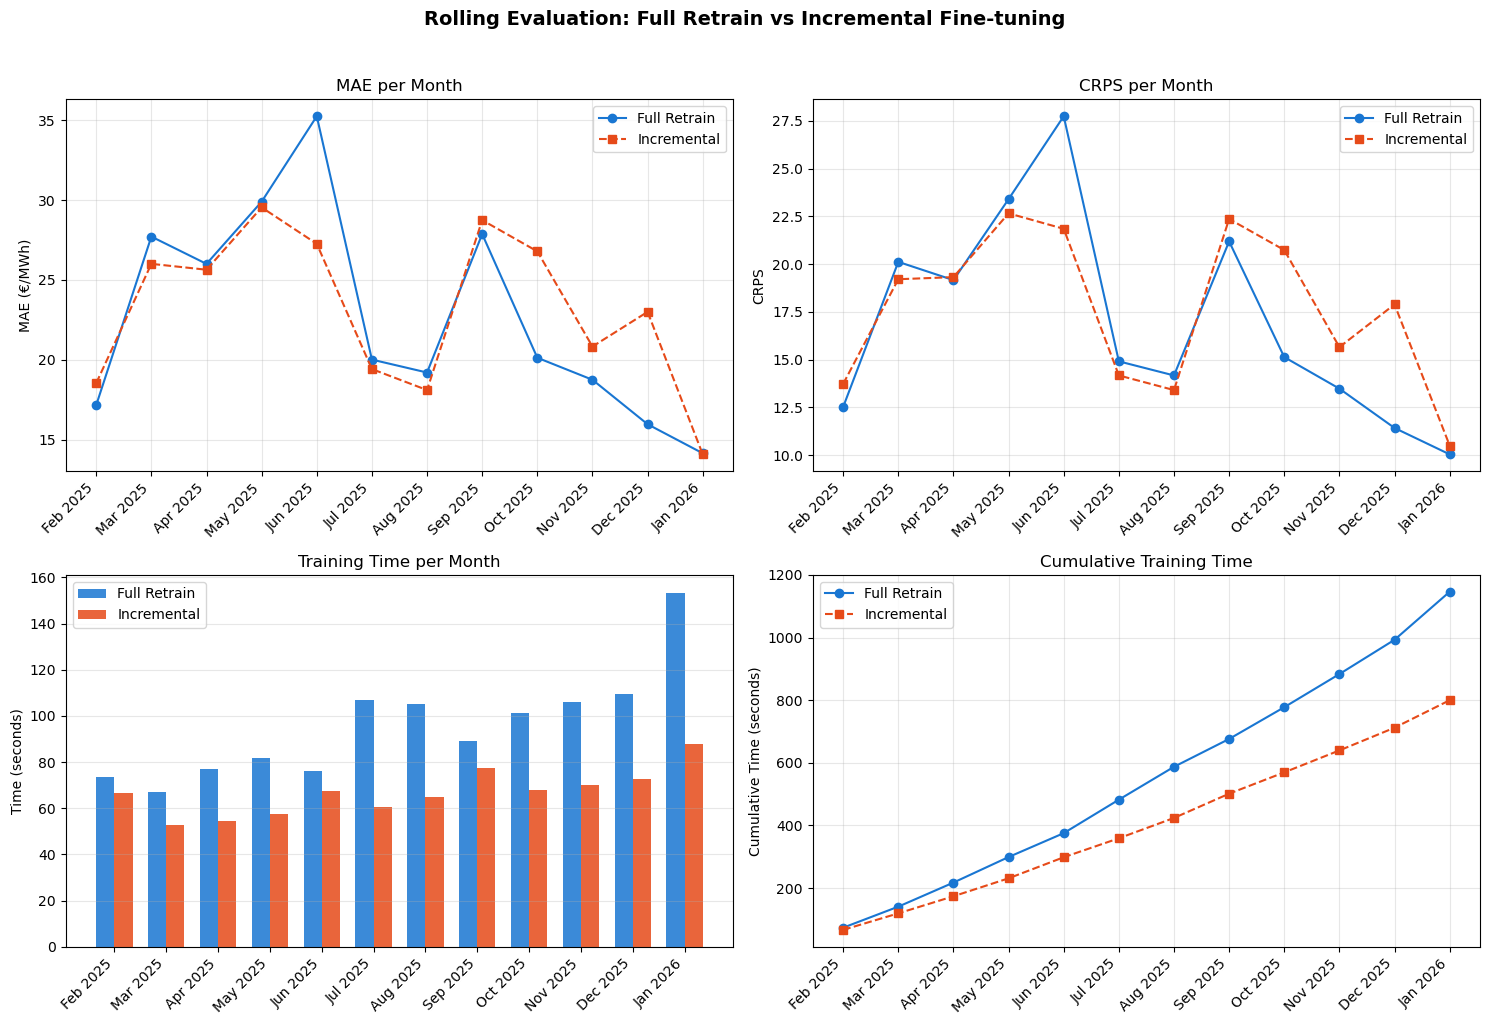

In [20]:
months = df_rt["month"]
x = np.arange(len(months))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1 — MAE per month
ax = axes[0, 0]
ax.plot(x, df_rt["MAE"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["MAE"], "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("MAE (\u20ac/MWh)")
ax.set_title("MAE per Month")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

# 2 — CRPS per month
ax = axes[0, 1]
ax.plot(x, df_rt["CRPS"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["CRPS"], "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("CRPS")
ax.set_title("CRPS per Month")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

# 3 — Training time per month
ax = axes[1, 0]
w = 0.35
ax.bar(x - w / 2, df_rt["training_time"], w, label="Full Retrain", color="#1976D2", alpha=0.85)
ax.bar(x + w / 2, df_ft["training_time"], w, label="Incremental", color="#E64A19", alpha=0.85)
ax.set_ylabel("Time (seconds)")
ax.set_title("Training Time per Month")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# 4 — Cumulative training time
ax = axes[1, 1]
ax.plot(x, df_rt["training_time"].cumsum(), "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["training_time"].cumsum(), "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("Cumulative Time (seconds)")
ax.set_title("Cumulative Training Time")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Rolling Evaluation: Full Retrain vs Incremental Fine-tuning",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rolling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

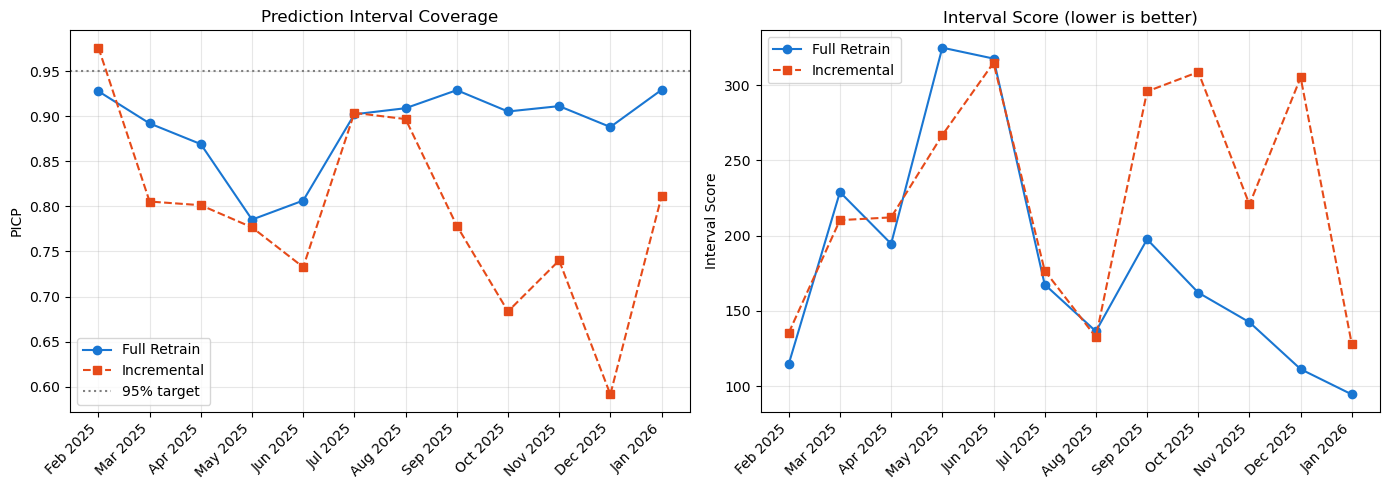

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x, df_rt["PICP"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["PICP"], "s--", label="Incremental", color="#E64A19")
ax.axhline(0.95, ls=":", color="gray", label="95% target")
ax.set_ylabel("PICP")
ax.set_title("Prediction Interval Coverage")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, df_rt["IntervalScore"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["IntervalScore"], "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("Interval Score")
ax.set_title("Interval Score (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "rolling_interval_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
df_rt.to_csv(RESULTS_DIR / "results_full_retrain.csv", index=False)
df_ft.to_csv(RESULTS_DIR / "results_incremental.csv", index=False)
print(f"Results saved to {RESULTS_DIR}")

Results saved to /home/d1ff1cult/masterproef_new/results/rolling_evaluation
